In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/Retail 2009-10.csv')
display(df.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085.0,United Kingdom


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB
None


In [ ]:
print('\nMissing values per column:')
display(df.isnull().sum())


Missing values per column:


,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


### Data Cleaning: Handling Missing Values and Data Types



In [ ]:
# Convert 'InvoiceDate' to datetime objects with the correct format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d-%m-%Y %H:%M')
print("InvoiceDate column converted to datetime.")

InvoiceDate column converted to datetime.


#### Handling 'Description' Missing Values


In [ ]:
df.dropna(subset=['Description'], inplace=True)
print(f"Rows after dropping missing descriptions: {len(df)}")

Rows after dropping missing descriptions: 522533


#### Handling 'Customer ID' Missing Values
The 'Customer ID' column has a significant number of missing values. For most retail analyses, a customer ID is essential to track purchasing behavior.

In [ ]:
df.dropna(subset=['Customer ID'], inplace=True)
print(f"Rows after dropping missing customer IDs: {len(df)}")

# Verify that there are no more missing values
print('\nMissing values per column after cleaning:')
display(df.isnull().sum())

Rows after dropping missing customer IDs: 417534

Missing values per column after cleaning:


,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [ ]:
print('\nUpdated DataFrame info:')
print(df.info())


Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 417534 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      417534 non-null  object        
 1   StockCode    417534 non-null  object        
 2   Description  417534 non-null  object        
 3   Quantity     417534 non-null  int64         
 4   InvoiceDate  417534 non-null  datetime64[ns]
 5   Price        417534 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      417534 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 28.7+ MB
None


### Data Analysis: Central Tendency

 mean, median, and mode for the numerical columns (`Quantity`, `Price`, `Customer ID`)

In [ ]:
numerical_cols = ['Quantity', 'Price', 'Customer ID']

display(df[numerical_cols].mean())
display(df[numerical_cols].median())
display(df[numerical_cols].mode())

,0
Quantity,12.758815
Price,3.887547
Customer ID,15360.645478


,0
Quantity,4.00
Price,1.95
Customer ID,15311.00


,Quantity,Price,Customer ID
0,1,1.25,14911.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate TotalPrice for each transaction
df['TotalPrice'] = df['Quantity'] * df['Price']
print("Added 'TotalPrice' column.")
display(df.head())

Added 'TotalPrice' column.


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


### Bar Chart: Top 10 Countries by Total Sales



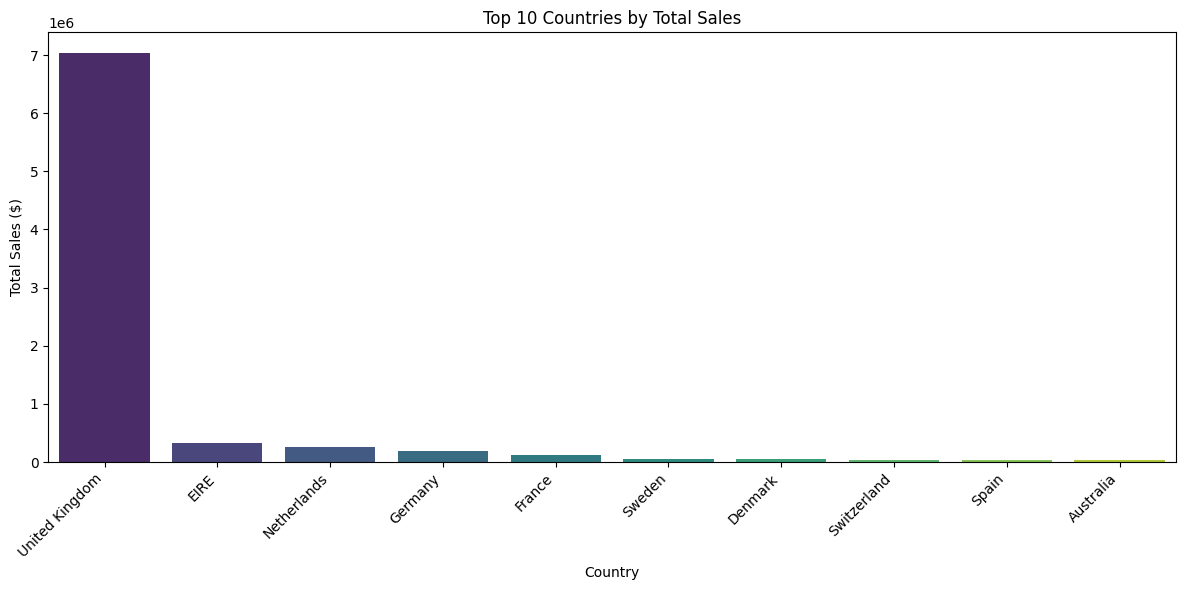

In [ ]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_sales.index, y=country_sales.values, palette='viridis', hue=country_sales.index, legend=False)
plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Line Plot: Daily Sales Trend

 how total sales evolve over time on a daily basis.

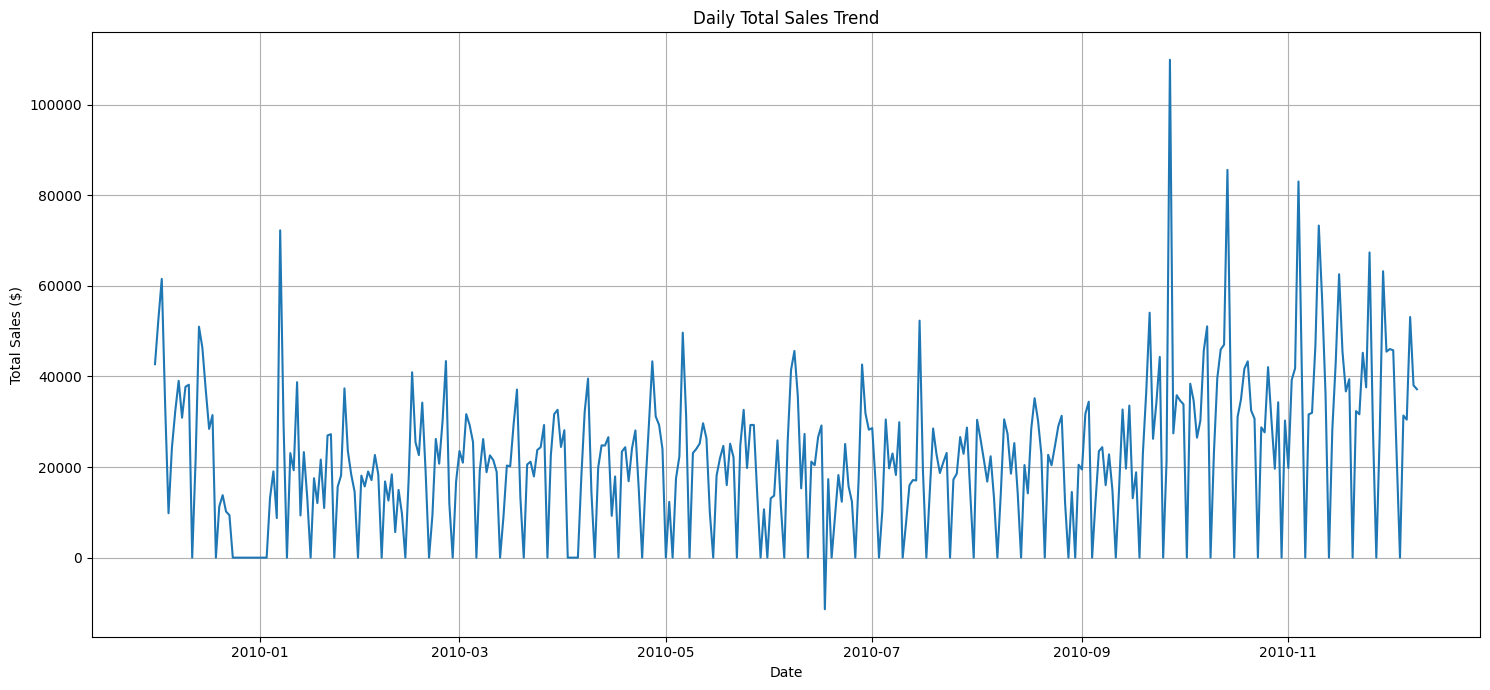

In [ ]:
daily_sales = df.set_index('InvoiceDate').resample('D')['TotalPrice'].sum().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x='InvoiceDate', y='TotalPrice', data=daily_sales)
plt.title('Daily Total Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Heatmap: Average Total Sales by Day of Week and Month

 heatmap showing the average total sales.

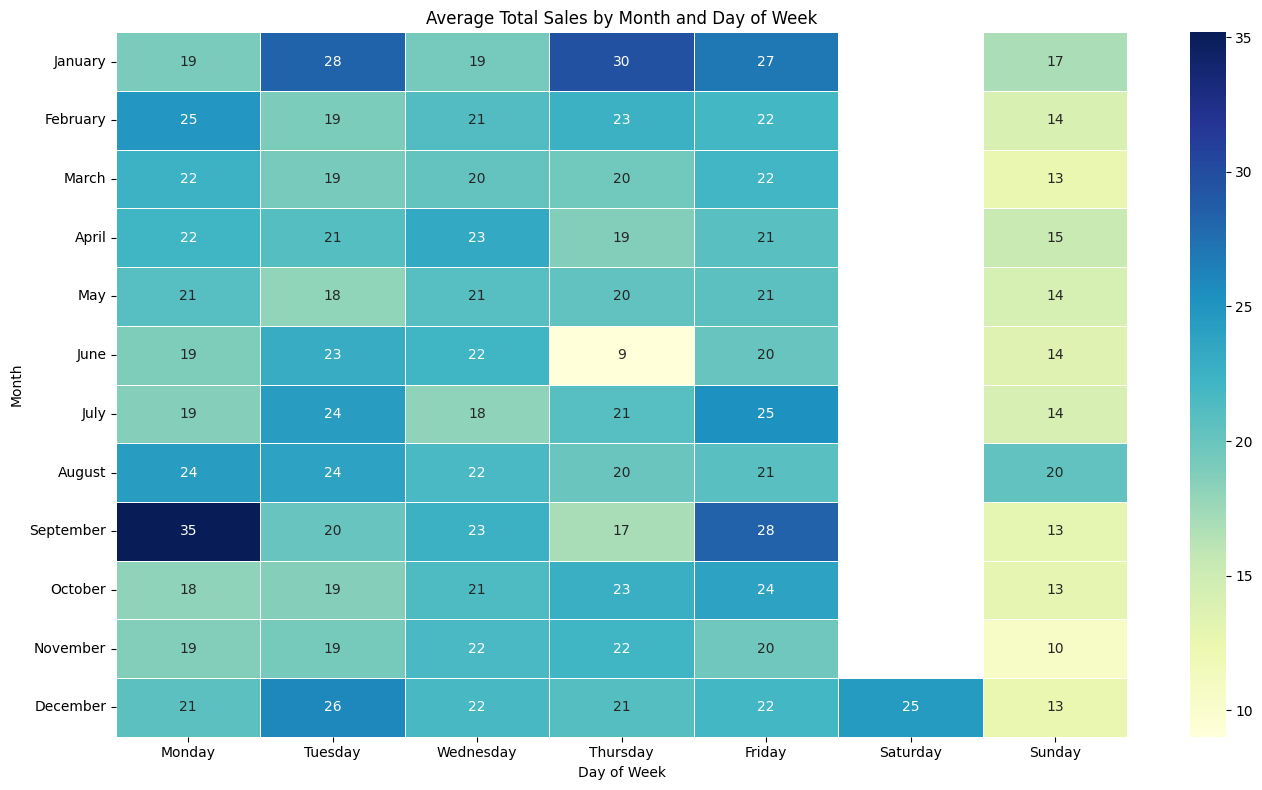

In [ ]:
# Extract day of week and month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Month'] = df['InvoiceDate'].dt.month_name()

# Define the order of days and months for better visualization
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# Create a pivot table for average sales
heatmap_data = df.pivot_table(values='TotalPrice', index='Month', columns='DayOfWeek', aggfunc='mean')

# Reindex to ensure correct order
heatmap_data = heatmap_data.reindex(index=month_order, columns=day_order)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap='YlGnBu', linewidths=.5)
plt.title('Average Total Sales by Month and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

### Recommendations Based on EDA

Based on the visualizations and data insights, here are some actionable recommendations:

1.  **Geographic Sales Concentration:** The United Kingdom accounts for a disproportionately large share of total sales. This indicates a strong domestic market but also potential for growth internationally.
    *   **Action:** Investigate the reasons for the UK's dominance (e.g., marketing efforts, established customer base, product relevance). Develop targeted strategies to expand market share in other high-potential countries (e.g., EIRE, Netherlands, Germany) or explore new markets.

2.  **Daily and Weekly Sales Patterns:**
    *   **Weekday vs. Weekend Sales:** The heatmap suggests that sales are generally lower on weekends (especially Saturday and Sunday for many months). This could indicate business-to-business (B2B) transactions dominating, or simply different customer behavior during weekends.
    *   **Action:** For B2B, focus marketing and outreach efforts more heavily during weekdays. For B2C, analyze if weekend promotions or specific product offerings could boost sales during these typically slower periods. It's also important to confirm if missing weekend data implies no sales or just data absence.

3.  **Identify Peak Sales Periods:** The daily sales trend shows fluctuations, and the heatmap highlights months and days with higher average sales.
    *   **Action:** Plan inventory, staffing, and marketing campaigns to capitalize on these peak periods. For instance, if certain weekdays in September and December show higher average sales, prepare for increased demand during those times.

4.  **Data Quality and Missing Values:** While 'Description' and 'Customer ID' missing values were handled, it's crucial to understand why `Quantity` or `Price` might be zero or negative, or if certain `InvoiceDate` periods have unusual gaps (like weekends). Also, `Customer ID` being a float suggests it might have been loaded incorrectly if it's meant to be an integer or string.
    *   **Action:** Review data collection processes to minimize missing customer IDs and ensure consistent data types. Investigate the source of `NaN` values for weekend sales in the heatmap to understand if it's a data limitation or actual zero sales.